## Handling Imbalanced Dataset

1. Up Sampling
2. Down Sampling

In [2]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [3]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [4]:
n_class_0,n_class_1

(900, 100)

In [5]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [6]:
!pip install scipy

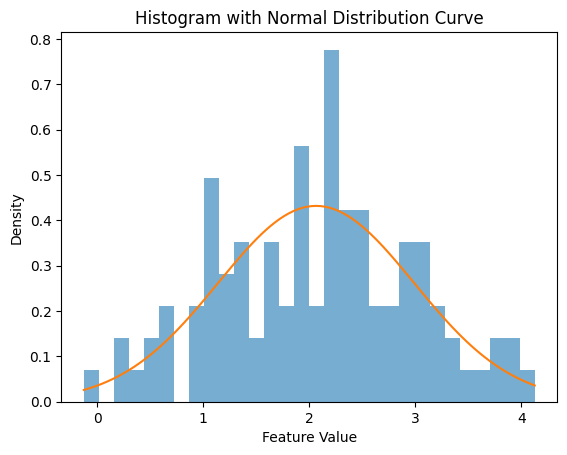

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# select one feature
data = class_1['feature_1']

# histogram
plt.hist(data, bins=30, density=True, alpha=0.6)

# mean and std
mu = data.mean()
sigma = data.std()

# x values for curve
x = np.linspace(data.min(), data.max(), 100)

# normal curve
y = norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.xlabel("Feature Value")
plt.ylabel("Density")
plt.title("Histogram with Normal Distribution Curve")
plt.show()


In [8]:
class_0

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
895,0.238761,-0.003155,0
896,-1.106386,-0.430660,0
897,0.366732,-0.146416,0
898,1.023906,1.160176,0


In [9]:
class_1

,feature_1,feature_2,target
0,1.699768,2.139033,1
1,1.367739,2.025577,1
2,1.795683,1.803557,1
3,2.213696,3.312255,1
4,3.033878,3.187417,1
...,...,...,...
95,1.376371,2.845701,1
96,2.239810,0.880077,1
97,1.131760,1.640703,1
98,2.902006,0.390305,1


In [10]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [11]:
df.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [12]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [13]:
## upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [16]:
!pip install scikit-learn

In [17]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

In [18]:
df_minority_upsampled.shape

(900, 3)

In [19]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [20]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [21]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## Down Sampling

In [22]:
import pandas as pd
import numpy as np
# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

# Check the class distribution
print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [23]:
## downsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [24]:
from sklearn.utils import resample

downsampledData=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=42)

In [25]:
downsampledData.shape

(100, 3)

In [27]:
downsampledData['target'].head()

70     0
827    0
231    0
588    0
39     0
Name: target, dtype: int64

In [28]:
downsampledData['target'].tail()


398    0
76     0
196    0
631    0
751    0
Name: target, dtype: int64